# **EDA California housing и эксперимент с деревьями**



In [72]:
from sklearn.datasets import fetch_california_housing
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


По тз требуется ноутбук с описанием шагов, по этому здесь будет оформлено несколько глав:
1. [**Разведывательный анализ**](####eda1);
2. [**Выбор модели**](####eda3);
3. [**Финальный вердикт и оценка решения**](####finall).

Наш датасет изначально подразумевает задачу регрессии - предсказание цены недвижимости по набору признаков.  

In [73]:
houses = fetch_california_housing()
houses

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

<a id="eda1"></a>
#### **Знакомство с датасетом**
Для удобства переведем текущие данные сразу же в датасет pandas(размеры не требуют большего).  
Мы имеем матрицу признаков 8 столбцов и 20640 строк, а так же столбец с целевой переменной.  
К датасету прилагается название фичей, название целевого столбца, а так же подробный description по структуре датасета.

In [74]:
df = pd.DataFrame(houses.data, columns=houses.feature_names)
df['MedHouseVal'] = houses.target

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


California Housing dataset  
  
Кол-во сущностей: 20640

Столбцы признаков: 8 шт. типа float64  
Пропуски и опечатки в датасете отсутствуют, как выяснилось из открытых источников.  

Информация об атрибутах:  
    - **MedInc** - Медианный доход( в десятках тыс. $);    
    - **HouseAge** - Медианный возраст жилья в районе;  
    - **AveRooms** - Среднее кол-во комнат в доме(для района);  
    - **AveBedrms** - Среднее кол-во спален в доме(для района);  
    - **Population** - Население района;  
    - **AveOccup** - Наполненность домов(кол-во домочадцев делить на кол-во домов)(для района);  
    - **Latitude** - Широта района;  
    - **Longitude** - Долгота района.  

 Целевая переенная **MedHouseVal** - медианная стоимость жилья(в сотнях тыс. $) в данном районе в соответствии с набором признаков.

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip


Набор данных датируется 1990 U.S. с соответствием одна строка-один район.

Нас так же предупреждают что в признаке **AveOccup** могут быть выбросы по причине наличия большого кол-ва домашних хозяйств, отелей, это мы учтем.

**ВАЖНО! Все дома дороже 500,000$ обрезаны до 5.0, по этому мы имеем большой выброс на распределении справа**


- Pace, R. Kelley and Ronald Barry, Sparse Spatial Autoregressions,
  Statistics and Probability Letters, 33:291-297, 1997.

<a id="eda2"></a>
#### **Постановка задачи**

 Так как у нас отсутствует опора на какую либо задачу, предположим что мы имеем сервис реализующий услуги помощи в продаже недвижимости, частью функционала которого является подбор цены для жилья.

<a id="eda3"></a>
#### **Анализ данных и генерация признаков**

In [75]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


На первый взгляд можно отметить значительные выбросы в AveRooms, AveBedrms, Population, AveOccup. С ними разберемся далее по ходу раскапывания датасета.  
  
Теперь я хочу посмотреть распределение данных целевой переменной(медианной стоимости домов).

<Axes: xlabel='MedHouseVal', ylabel='Count'>

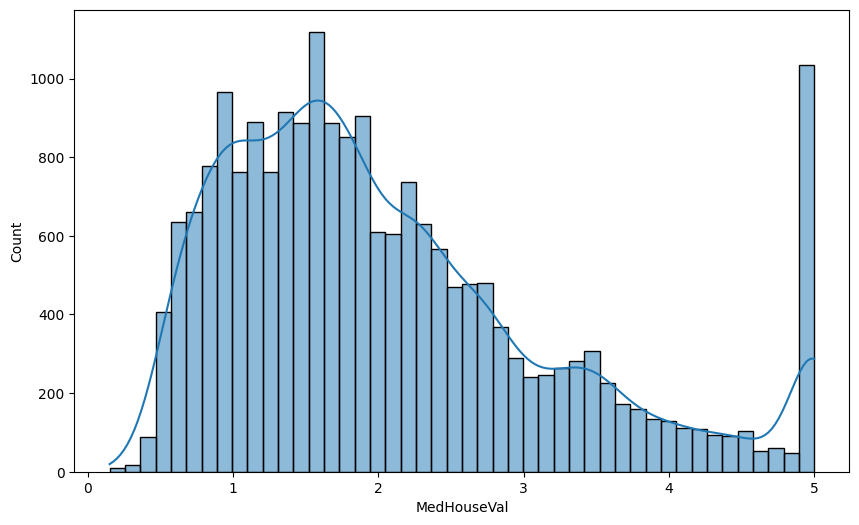

In [76]:
plt.figure(figsize=(10, 6))
sns.histplot(df['MedHouseVal'], bins='auto', kde=True)

Видим сдвиг влево основной массы цен, а так же большой хвост на уровне 5 у.е.(как уже упоминалось, намеренное округление до 5.0 всего что > 5.0). Выделим новый признак, который бы качественно разделил сущности на входящие в ценовой диапазон и на то что выше. По округлению можно сделать вывод что наш сервис будет расчитан на определенную аудиторию с определенным бюджетом.

<Axes: xlabel='is_capped', ylabel='MedInc'>

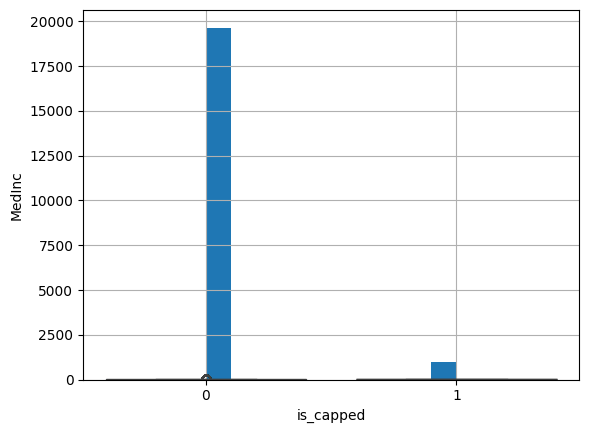

In [77]:
idx = df.columns.to_list().index('MedHouseVal')
df.insert(idx, 'is_capped', (df['MedHouseVal'] >= 5.0).astype(int))
sns.boxplot(data=df, x='is_capped', y='MedInc')
df['is_capped'].hist()

Видим что в основном доминирует группа до 5.0 у.е., однако признак не будет использоваться при обучении модели, так как это будет Data Leakage.

<Axes: >

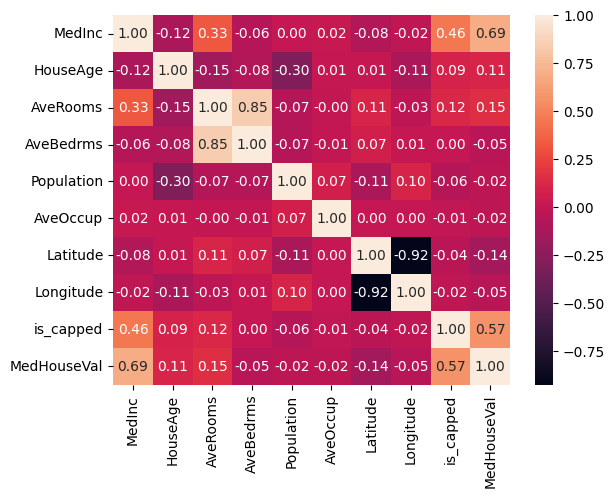

In [78]:
sns.heatmap(df.corr(), annot=True, fmt='.2f')

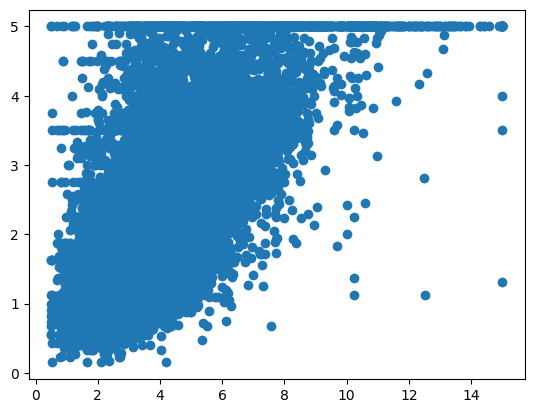

In [79]:
plt.scatter(df['MedInc'], df['MedHouseVal'])

Корреляционный анализ показал, что только MedInc имеет выраженную линейную связь с целевой переменной (r = 0.68), и все же имеет форму расширяющегося облака. Остальные признаки имеют низкую линейную корреляцию (0.03–0.12), что указывает на возможный нелинейный характер зависимостей. is_capped тоже имеет высокий показатель корреляции(r = 0.57), однако это из-за большого выброса в параметре 0.5.

Далее я проверю еще несколько зависимостей, которые, вероятно, не показала карта корреляций.

Меня интересуют показатели долготы и широты, которые потенциально вместе могут влиять на стоимость жилья в районе. Ведь чем ближе условный район к центру города, тем он, зачастую, обеспеченнее и благополучнее.

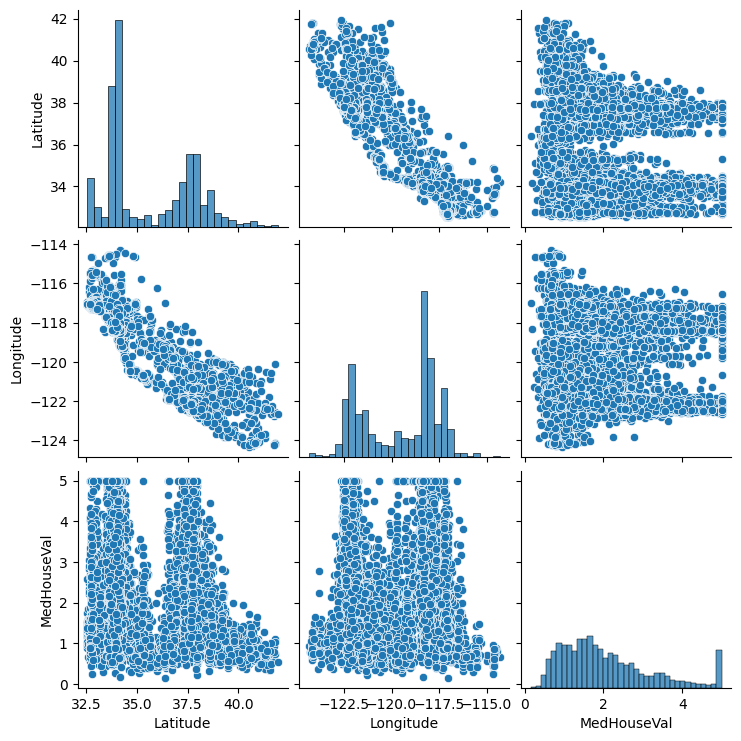

In [80]:
sns.pairplot(df[['Latitude', 'Longitude', 'MedHouseVal']].sample(10000))

Рассмотрев ближе распределение данных признаком можно сказать что мы имеем два больших центра. По сути это расстояние от Лос-Анджелеса до Сан-Франциско, если вывести scatter из широты и долготы можно напрямую разглядеть очертания побережья.

<Axes: xlabel='Longitude', ylabel='Latitude'>

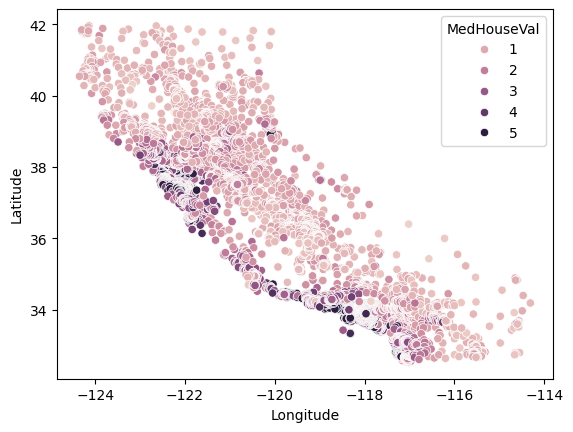

In [81]:
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='MedHouseVal')


Общая картина показывает что чем мы ближе к Калифорнийскому побережью, тем выше средняя цена на недвижимость. Тем не менее, близость к центрам так же влияет на стоимость, это можно заметить наложив получившуюся картину на карту от Сан-Франциско. Предлагаю провести кластеризацию по районам и добавить это как вспомогательный признак. 

In [82]:
# district = df[['Latitude', 'Longitude']]
# result = []
# for i in range(2, 52):
#     km = KMeans(n_clusters=i, random_state=0, n_init=15)
#     labels = km.fit_predict(district)
#     score = silhouette_score(district, labels)
#     print(score)
#     result.append(score)
# plt.scatter(np.arange(2, 52), result)
# 7
km = KMeans(n_clusters=7, random_state=0, n_init=25)
idx = df.columns.to_list().index('MedHouseVal')
df.insert(idx, 'region', km.fit_predict(df[['Latitude', 'Longitude']]))


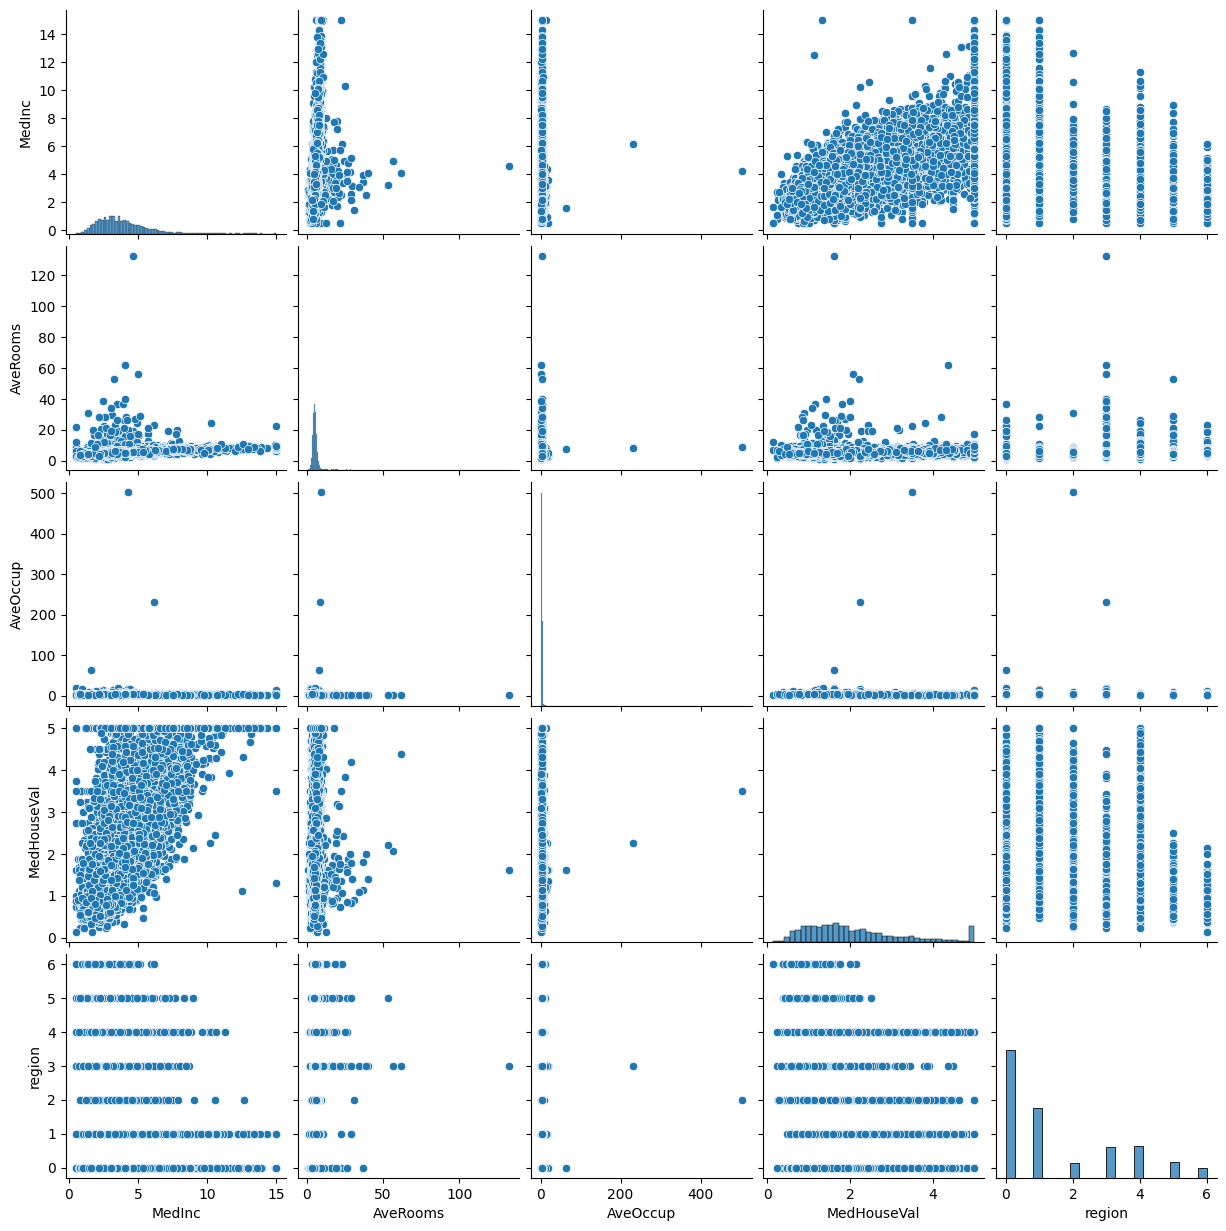

In [83]:
sns.pairplot(df[['MedInc', 'AveRooms', 'AveOccup', 'MedHouseVal', 'region']].sample(10000))

<a id="eda3"></a>
#### **Выбор модели**

Не смотря на наличие некоторой линейности, ее недостаточно для качественного предсказания и хорошего показателя R^2. По этому в качестве наиболее подходящих алгоритмов для тестов выбраны RandomForestRegressor, XGBoost, CatBoost так как:
1. Распределение не является нормальным, сдвинуто влево и имеет большой выброс, который нельзя удалить ибо он несет важную информацию;
2. Мы имеем весомые не линейные признаки, такие как широта и долгота, которые делают большой вклад в решение;
3. Мы имеем вторичные признаки, работающие в совокупности, например Population и MedInc.

Протестированы будут модели:
1. Напрямую к данным;
2. Каскадным методом classifier(для is_capped) и regressor(для MedHouseVal):  
    1) Классификатор. Будем считать что показатель >= 5.0 это True(премиум сегмент) а все что <5.0 это False(обычный).
    2) Регрессор. Используем для финального вердикта цены, если выяснилось, что строка подходит под понятие недвижимости, ниже 5.0, т.е. обычного сегмента.


In [84]:
df.to_csv('start_df.csv')

<a id="finall"></a>
#### **Финальный вывод**

Можно заключить, что эксперимент с каскадом оказался удачный.  В данном случае считаю именно такую комплектацию гиперпараметров для XGBoost наиболее подходящей. Далее можно экспортировать параметры и заняться внедрением модели.
Наша конфигурация:
- Классификатор **XGBClassifier** (n_estimators=200, max_depth=4, learning_rate=0.2)
- Классификатор **XGBRegressor** (n_estimators=150, max_depth=6, learning_rate=0.05)
- Дополнительный бинарный параметр для домов дешевле/дороже 5.0 у.е. который оказал важнейшее положительное влияние на наши показатели.

Итоговые показатели:
 - **MAE - 0.251**
 - **MSE - 0.386**
 - **R2 - 0.888**